# Praktikum 1: Simulasi Monte Carlo dengan Komputasi Paralel

In [1]:
import threading
import numpy as np
import time

N = 1000000

# Fungsi hitung skala kecil untuk setiap thread
def simulasi_sebagian(n_partisi, hasil_list, index):
    x_part = np.random.rand(n_partisi)
    y_part = np.random.rand(n_partisi)
    hasil_list[index] = np.sum((x_part**2 + y_part**2) <= 1)

# Fungsi utama pengujian paralel berbasis Thread
def ambil_waktu_thread(jumlah_thread):
    titik_per_thread = N // jumlah_thread
    threads = []
    hasil = [0] * jumlah_thread
    
    start_time = time.time()
    
    # Membuat dan menjalankan thread
    for i in range(jumlah_thread):
        t = threading.Thread(target=simulasi_sebagian, args=(titik_per_thread, hasil, i))
        threads.append(t)
        t.start()
        
    # Menunggu semua thread selesai
    for t in threads:
        t.join()
        
    end_time = time.time()
    return end_time - start_time

if __name__ == '__main__':
    # Angka patokan sekuensial asli dari laptopmu tadi
    waktu_serial = 0.08590 
    
    daftar_proses = [2, 4, 8, 16, 32]
    
    print("--- HASIL OTOMATIS UNTUK TABEL 2.2 ---")
    # Baris 1
    print(f"Proses 1  -> Waktu: {waktu_serial:.5f} s | Speedup: 1.00 | Efficiency: 1.00")
    
    # Hitung otomatis untuk baris sisanya
    for p in daftar_proses:
        waktu_paralel = ambil_waktu_thread(p)
        speedup = waktu_serial / waktu_paralel
        efficiency = speedup / p
        print(f"Proses {p:<2} -> Waktu: {waktu_paralel:.5f} s | Speedup: {speedup:.2f} | Efficiency: {efficiency:.2f}")

--- HASIL OTOMATIS UNTUK TABEL 2.2 ---
Proses 1  -> Waktu: 0.08590 s | Speedup: 1.00 | Efficiency: 1.00
Proses 2  -> Waktu: 0.09245 s | Speedup: 0.93 | Efficiency: 0.46
Proses 4  -> Waktu: 0.04835 s | Speedup: 1.78 | Efficiency: 0.44
Proses 8  -> Waktu: 0.03628 s | Speedup: 2.37 | Efficiency: 0.30
Proses 16 -> Waktu: 0.04048 s | Speedup: 2.12 | Efficiency: 0.13
Proses 32 -> Waktu: 0.03813 s | Speedup: 2.25 | Efficiency: 0.07


## Grafik Analisis Perbandingan Performa Speedup

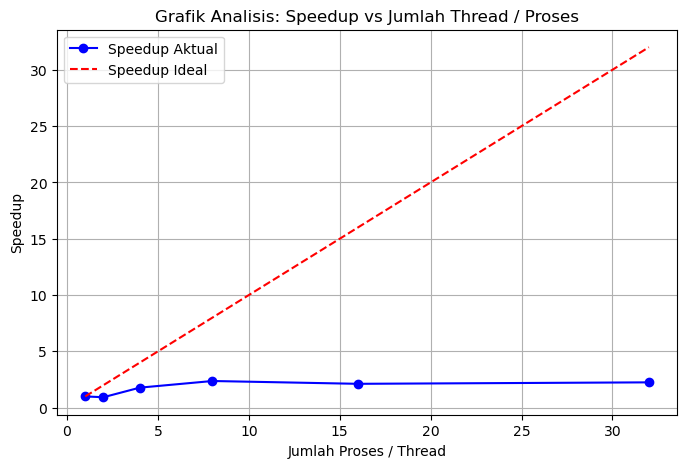

In [2]:
import matplotlib.pyplot as plt

# 1. Masukkan data asli dari tabel Word kamu
jumlah_proses = [1, 2, 4, 8, 16, 32]
speedup_aktual = [1.00, 0.93, 1.78, 2.37, 2.12, 2.25]

# 2. Membuat data untuk Speedup Ideal (garis lurus putus-putus sebagai pembanding)
speedup_ideal = [1, 2, 4, 8, 16, 32]

# 3. Mengatur ukuran dan desain grafik
plt.figure(figsize=(8, 5))
plt.plot(jumlah_proses, speedup_aktual, marker='o', color='blue', label='Speedup Aktual')
plt.plot(jumlah_proses, speedup_ideal, linestyle='--', color='red', label='Speedup Ideal')

# 4. Memberikan label teks pada grafik
plt.title('Grafik Analisis: Speedup vs Jumlah Thread / Proses')
plt.xlabel('Jumlah Proses / Thread')
plt.ylabel('Speedup')
plt.grid(True)
plt.legend()

# 5. Menampilkan grafik
plt.show()